In [10]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import cmasher as cmr
import matplotlib.pyplot as plt
import seaborn as sns

### Header definitions:

| Keyword  | Units  | Explanation                                                   |
| -------- | ------ | ------------------------------------------------------------- |
| SIMPLE   |        | Indicates that it is standard FITS file.                      |
| BITPIX   |        | Data type of pixel values.                                    |
| NAXIS    |        | Dimensions of file.                                           |
| NAXIS1   | pixels | Number of pixels along the first axis (RA).                   |
| NAXIS2   | pixels | Number of pixels along the second axis (Dec).                 |
| NAXIS3   | pixels | Number of pixels along the third axis (frequency).            |
| NAXIS4   | pixels | Number of pixels along the fourth axis (Stokes/polarization). |
| EXTEND   |        | Indicates that the file may contain extensions.               |
| BSCALE   |        | Linear scaling factor applied to pixel values.                |
| BZERO    |        | Offset applied to pixel values in conjuction with BSCALE      |
| BMAJ     | deg    | Major axis of the beam.                                       |
| BMIN     | deg    | Minor axis of the beam.                                       |
| BPA      | deg    | Position angle of the beam (east of north).                   |
| BTYPE    |        | Type of data contained in pixels.                             |
| BUNIT    |        | Units of pixel values                                         |
| OBJECT   |        | Name of observed target.                                      |
| TELESCOP |        | Telescope used.                                               |
| INSTRUME |        | Instrument used.                                              |
| OBSERVER |        | Name of the observer.                                         |
| DATE-OBS |        | Date and time of observation.                                 |
| DISTANCE | pc     | Distance to the source.                                       |
| FIELD    |        | Observing field (for example, target name or region of sky).  |
| INTENT   |        | Purpose of observation                                        |
| RADESYS  |        | Reference coordinate system.                                  |
| LONPOLE  | deg    | Longitude of celestial pole.                                  |
| LATPOLE  | deg    | Latitude of celestial pole.                                   |
| PCi_j    |        | Matrix elements used to map pixels to physical coordinates.   |
| CTYPE1   |        | Coordinate type of first axis (RA projection).                |
| CTYPE2   |        | Coordinate type of second axis (Dec projection).              |
| CRVAL1   | deg    | Coordinate value at reference pixel for first axis.           |
| CRVAL2   | deg    | Coordinate value at reference pixel for second axis.          |
| CDELT1   | deg    | Pixel scale along first axis.                                 |
| CDELT2   | deg    | Pixel scale along second axis.                                |
| CRPIX1   | pixels | Reference pixel along first axis.                             |
| CRPIX2   | pixels | Reference pixel along second axis.                            |
| CUNIT1   | deg    | Units for first axis (RA).                                    |
| CUNIT2   | deg    | Units for second axis (Dec).                                  |
| CTYPE3   |        | Type of third axis (frequency).                               |
| CRVAL3   | Hz     | Coordinate value at reference pixel for third axis.           |
| CDELT3   | Hz     | Pixel scale along third axis.                                 |
| CRPIX3   | pixels | Reference pixel along third axis.                             |
| CUNIT3   | Hz     | Units for third axis (frequency).                             |
| RESTFRQ  | Hz     | Rest frequency of observed line.                              |
| SPECSYS  |        | Spectral reference frame.                                     |
| VELREF   |        | Velocity reference value.                                     |
| CTYPE4   |        | Type of fourth axis (Stokes/polarization).                    |
| CRVAL4   |        | Coordinate value at reference pixel for fourth axis.          |
| CDELT4   |        | Spacing between Stokes parameters.                            |
| CRPIX4   | pixels | Reference pixel along fourth axis.                            |
| CUNIT4   |        | Units for fourth axis                                         |
| ALTRVAL  | Hz     | Alternate reference value.                                    |
| ALTRPIX  | pixels | Pixel for alternate frequency reference.                      |
| SPECMODE |        | Data formatting.                                              |
| SPW      |        | Spectral window number.                                       |
| TYPE     |        | Image type.                                                   |
| DATE     |        | Date of file creation.                                        |
| ORIGIN   |        | File software.                                                |



### Opening FITS file and defining important variables:

In [3]:
# object = fits.open('HD163296_cube.fits')
object = fits.open('CS-97dot9-dot98.FITS')
object.info()

vslr = 5.8  # km/s

fulldata = object[0].data  # accessing data from primary HDU
imdata = np.squeeze(fulldata[0].data)  # load image data into extra axis; intensity in Jy/beam and frequency in Hz

hdr = object[0].header  # accessing header from primary HDU
restfrq = hdr['RESTFRQ']   # Hz
beam_pa = hdr['BPA']  # degrees
theta_maj = (hdr['BMAJ'] * u.deg).to(u.arcsec) # arcsec
theta_min = (hdr['BMIN'] * u.deg).to(u.arcsec) # arcsec
pix_size = (hdr['CDELT1'] * u.deg).to(u.arcsec)  # arcsec
nchan = imdata.shape[0] # number of channels
start_frequency = hdr['CRVAL3'] # Hz
channel_width = hdr['CDELT3'] # Hz
rest_frequency = hdr['RESTFRQ'] # Hz


Filename: CS-97dot9-dot98.FITS
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (840, 840, 1918, 1)   float32   


### Defining channel of source velocity rest emission and plotting channel map in arcseconds:

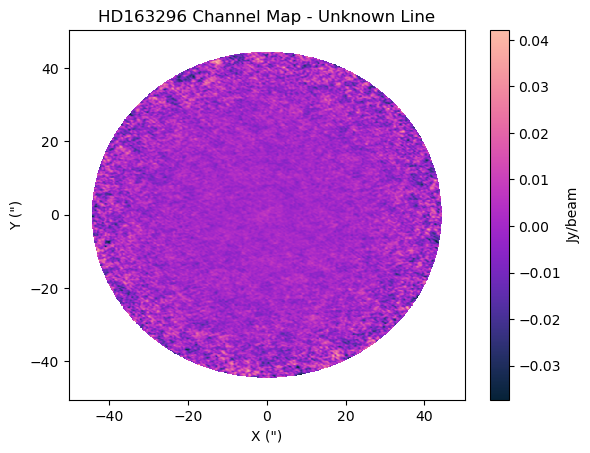

In [4]:
xoffs = hdr['CRVAL1'] + np.array([nn*hdr['CDELT1'] for nn in range(hdr['NAXIS1'])])
yoffs = hdr['CRVAL2'] + np.array([nn*hdr['CDELT2'] for nn in range(hdr['NAXIS2'])])

xvals = np.array(xoffs - xoffs[int(hdr['NAXIS1']/2)]) * u.deg.to(u.arcsec)
yvals = np.array(yoffs - yoffs[int(hdr['NAXIS2']/2)]) * u.deg.to(u.arcsec)


target_rest_freq = restfrq # Hz
target_freq = target_rest_freq * (1 - vslr/3e5) 
channel = int(round((target_freq - start_frequency)/channel_width))

image = plt.pcolormesh(xvals, yvals, imdata[channel,:, :], cmap='cmr.bubblegum')
plt.colorbar(label=hdr.get('BUNIT', 'Jy/beam'))
plt.title(f"{hdr.get('OBJECT', 'Unknown Object')} Channel Map - {hdr.get('LINE', 'Unknown Line')}")
plt.xlabel('X (")')
plt.ylabel('Y (")')
plt.show()


### Plotting moment0 map:

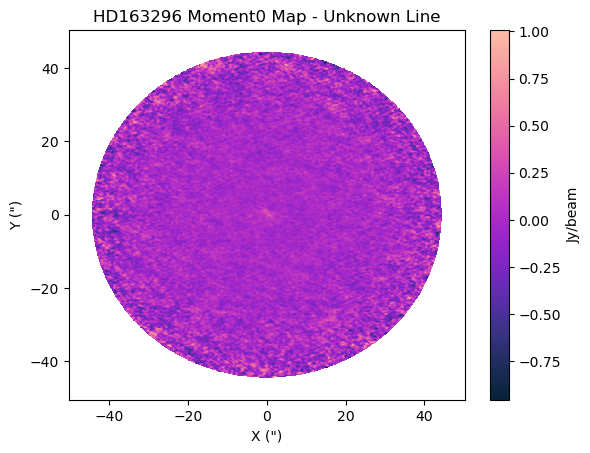

In [5]:
moment0 = np.sum(imdata, axis=0) 
image = plt.pcolormesh(xvals, yvals, moment0, cmap='cmr.bubblegum')
plt.colorbar(label=hdr.get('BUNIT', 'Jy/beam'))
plt.title(f"{hdr.get('OBJECT', 'Unknown Object')} Moment0 Map - {hdr.get('LINE', 'Unknown Line')}")
plt.xlabel('X (")')
plt.ylabel('Y (")')
plt.show()

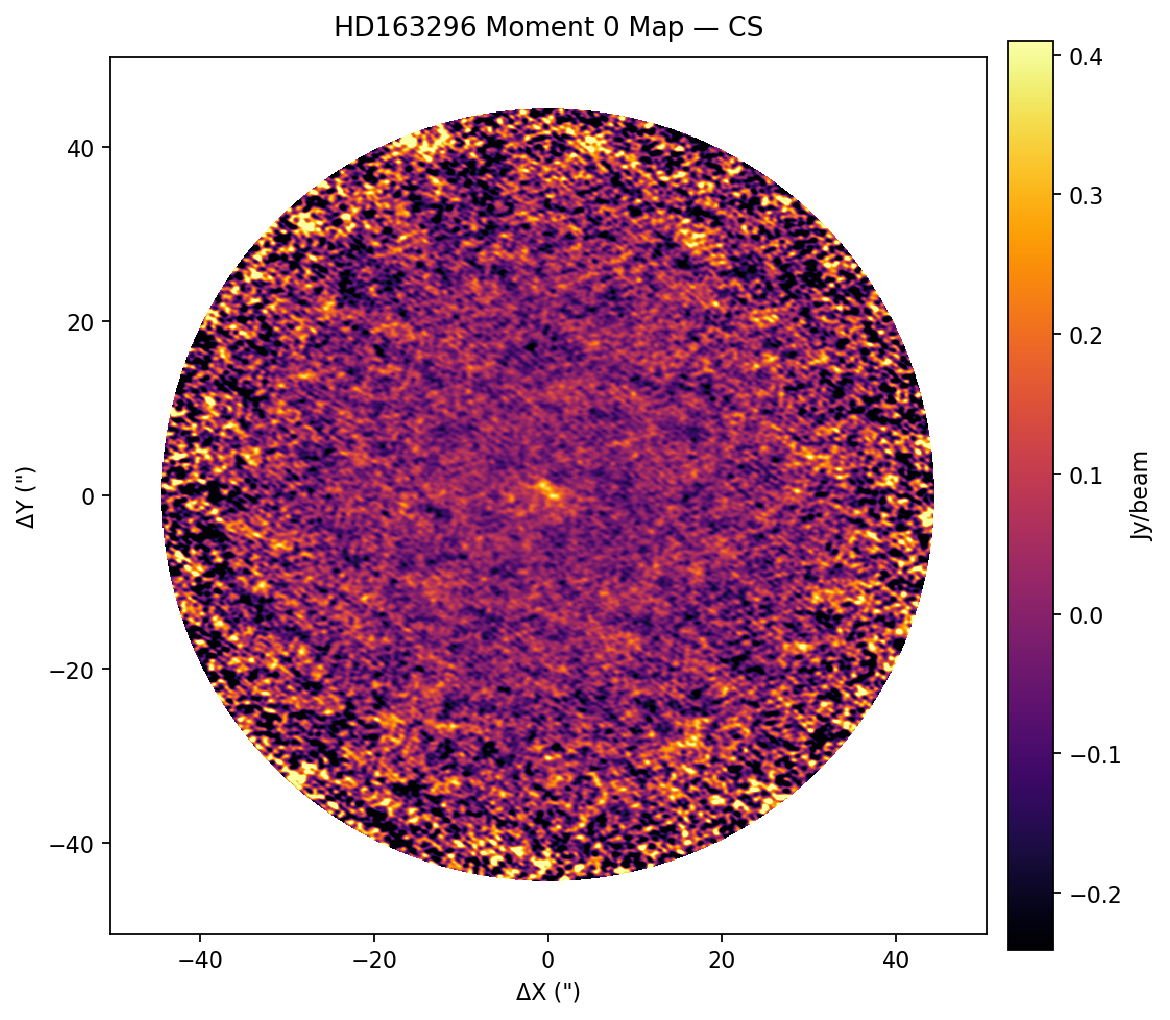

In [8]:
moment0 = np.sum(imdata, axis=0)

plt.figure(figsize=(7.5, 6.5), dpi=160)

vmin, vmax = np.nanpercentile(moment0, [5, 99])

image = plt.pcolormesh(
    xvals, yvals, moment0,
    cmap="inferno",
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(image, pad=0.02)
cbar.set_label(hdr.get('BUNIT', 'Jy/beam'))

plt.title(f"{hdr.get('OBJECT', 'Unknown Object')} Moment 0 Map — {hdr.get('LINE', 'CS')}", pad=10)
plt.xlabel('ΔX (")')
plt.ylabel('ΔY (")')

plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
# plt.savefig("CS_moment0.png", dpi=400, bbox_inches="tight")
plt.show()

### Plotting spectrum in terms of veloicty, centered on source velocity rest emission

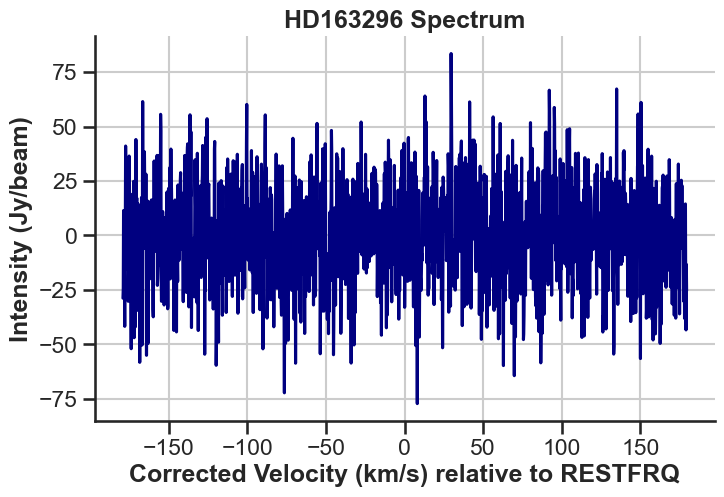

In [12]:
frequencies = start_frequency + channel_width * np.arange(nchan)  # Hz
velocities = ((rest_frequency - frequencies)/rest_frequency * 3e5)  # km/s
velocities_corr = velocities - vslr

spectrum = np.nansum(imdata, axis=(1,2))  # Jy/beam

plt.figure(figsize=(8,5))
plt.plot(velocities_corr, spectrum, color='navy')
plt.xlabel("Corrected Velocity (km/s) relative to RESTFRQ")
plt.ylabel(f"Intensity ({hdr.get('BUNIT','Unknown Unit')})")
plt.title(f"{hdr.get('OBJECT','Unknown Object')} Spectrum")
plt.grid(True)
plt.show()


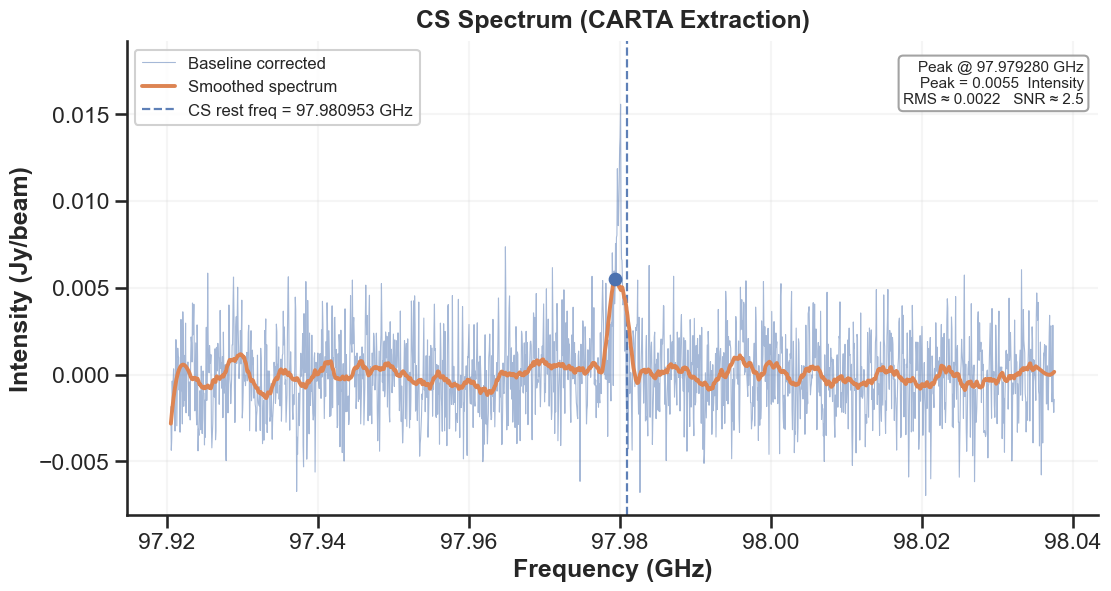

In [19]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

DATA_FILE = "CS-97.98.tsv"

df = pd.read_csv(DATA_FILE, sep="\t", comment="#", header=None, names=["x", "y"]).dropna()
df = df.sort_values("x")

x = df["x"].to_numpy(float)
y = df["y"].to_numpy(float)

# Baseline correction
y0 = y - np.median(y)

# Smoothed spectrum
SMOOTH_WINDOW = 81
SMOOTH_POLY = 3

w = SMOOTH_WINDOW
if w % 2 == 0:
    w += 1
if w >= len(y0):
    w = len(y0) - 1
if w % 2 == 0:
    w -= 1

y_s = savgol_filter(y0, window_length=w, polyorder=SMOOTH_POLY)

# Peak
peak_idx = np.argmax(y_s)
peak_x = x[peak_idx]
peak_y = y_s[peak_idx]

# RMS + SNR from edges
edge = max(10, int(0.1 * len(y0)))
rms = np.std(np.r_[y0[:edge], y0[-edge:]])
snr = peak_y / rms

# Plot labels/constants
REST_FREQ = 97.980953
TITLE = "CS Spectrum (CARTA Extraction)"
X_LABEL = "Frequency (GHz)"
Y_LABEL = "Intensity (Jy/beam)"

USE_INSET = False
INSET_HALF_WIDTH_GHZ = 0.003

sns.set_theme(style="ticks", context="talk")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(11, 5.8), constrained_layout=True)

ax.plot(x, y0, lw=0.8, alpha=0.5, label="Baseline corrected", zorder=1)

ax.plot(x, y_s, lw=2.8, label="Smoothed spectrum", zorder=3)

ax.axvline(REST_FREQ, ls="--", lw=1.6, alpha=0.9, label=f"CS rest freq = {REST_FREQ:.6f} GHz", zorder=2)

ax.scatter([peak_x], [peak_y], s=70, zorder=4)

ax.set_title(TITLE, pad=10)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)

ax.grid(True, alpha=0.18)

ax.legend(framealpha=0.9, fontsize=12)

info = (
    f"Peak @ {peak_x:.6f} GHz\n"
    f"Peak = {peak_y:.3g}  {Y_LABEL.split('(')[0].strip()}\n"
    f"RMS ≈ {rms:.2g}   SNR ≈ {snr:.1f}"
)
ax.text(
    0.985, 0.96, info,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="0.6",
        alpha=0.9
    )
)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.15)

if USE_INSET:
    axins = inset_axes(ax, width="33%", height="45%", loc="lower right", borderpad=1.0)
    axins.plot(x, y0, lw=0.7, alpha=0.18)
    axins.plot(x, y_s, lw=2.2)
    axins.axvline(REST_FREQ, ls="--", lw=1.2, alpha=0.9)
    axins.scatter([peak_x], [peak_y], s=35, zorder=4)

    x1, x2 = REST_FREQ - INSET_HALF_WIDTH_GHZ, REST_FREQ + INSET_HALF_WIDTH_GHZ
    axins.set_xlim(x1, x2)

    mask = (x >= x1) & (x <= x2)
    yy = y0[mask]
    if yy.size > 0:
        yymin, yymax = float(np.min(yy)), float(np.max(yy))
        axins.set_ylim(yymin - 0.15*(yymax-yymin), yymax + 0.25*(yymax-yymin))

    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title("Zoom", fontsize=12, pad=4)
    mark_inset(ax, axins, loc1=2, loc2=4,
           fc="none", ec="0.5", lw=0.8)

    for spine in axins.spines.values():
        spine.set_linewidth(1)
        spine.set_color("0.4")